# Efficiency & Outcome Analysis

## Objective

Evaluate the efficiency and consistency of movement through the UAC care pipeline using aggregate transfer, discharge, and throughput measures.

## Business Questions

- How does transfer efficiency change over time?
- How does discharge effectiveness change over time?
- Is pipeline throughput improving or declining?
- Are operational outcomes relatively stable or highly variable?
- Which periods show unusually low or high efficiency?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/uac_eda.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,apprehended,cbp_custody,transferred,hhs_care,discharged,month,year,cbp_net_pressure,hhs_net_pressure,day_of_week
0,2023-01-12,33.0,53.0,34.0,6566,436.0,2023-01,2023,-1.0,-402.0,Thursday
1,2023-01-22,32.0,49.0,39.0,7122,227.0,2023-01,2023,-7.0,-188.0,Sunday
2,2023-01-23,32.0,50.0,39.0,7280,181.0,2023-01,2023,-7.0,-142.0,Monday
3,2023-01-24,47.0,42.0,47.0,7433,175.0,2023-01,2023,0.0,-128.0,Tuesday
4,2023-01-25,20.0,22.0,41.0,7538,180.0,2023-01,2023,-21.0,-139.0,Wednesday


## 5.1 Transfer Efficiency Analysis

### Business Question

How does transfer efficiency vary across the observation period?

### Description

Transfer Efficiency Ratio measures transfer activity relative to the number of children recorded in CBP custody.

The measure provides an aggregate indication of how transfer activity changes relative to the CBP custody population.

In [2]:
df["transfer_efficiency"] = np.where(
    df["cbp_custody"] > 0,
    df["transferred"] / df["cbp_custody"],
    np.nan
)

df[[
    "date",
    "cbp_custody",
    "transferred",
    "transfer_efficiency"
]].head()

,date,cbp_custody,transferred,transfer_efficiency
0,2023-01-12,53.0,34.0,0.641509
1,2023-01-22,49.0,39.0,0.795918
2,2023-01-23,50.0,39.0,0.780000
3,2023-01-24,42.0,47.0,1.119048
4,2023-01-25,22.0,41.0,1.863636


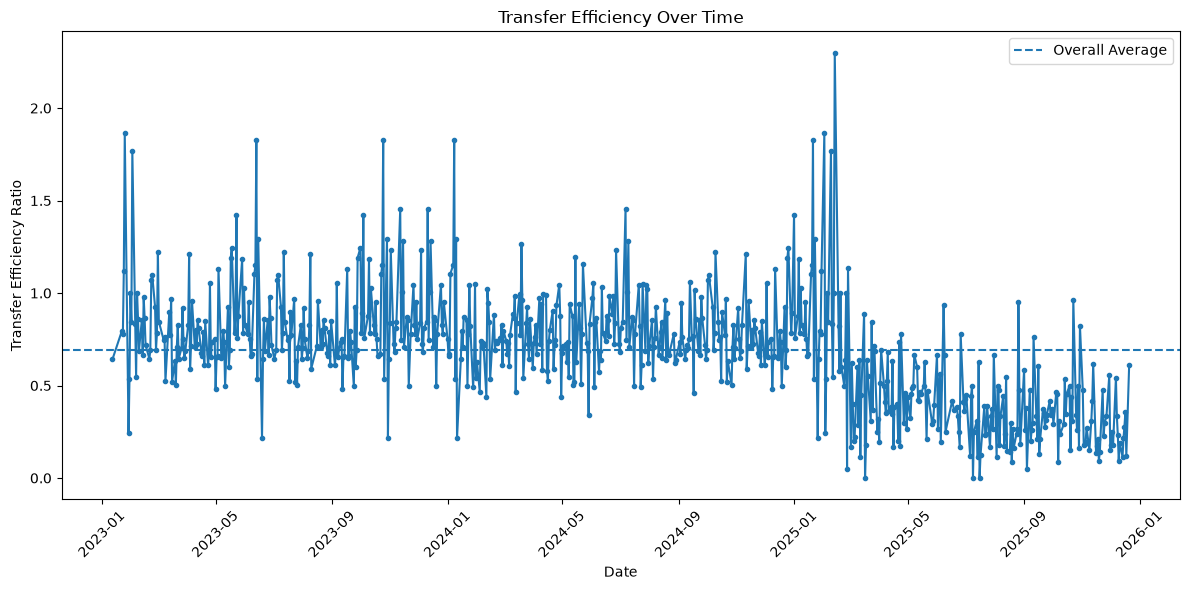

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["transfer_efficiency"],
    marker="o",
    markersize=3
)

plt.axhline(
    df["transfer_efficiency"].mean(),
    linestyle="--",
    label="Overall Average"
)

plt.title("Transfer Efficiency Over Time")
plt.xlabel("Date")
plt.ylabel("Transfer Efficiency Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 1: Transfer Efficiency Over Time

### Key Finding

Transfer efficiency varies across reporting periods, indicating changes in transfer activity relative to the CBP custody population.

### Business Implication

Monitoring changes in transfer efficiency can help identify periods where movement out of CBP custody was comparatively lower or higher than usual.

## 5.2 Discharge Effectiveness Analysis

### Business Question

How does discharge activity vary relative to the population in HHS care?

### Description

Discharge Effectiveness measures the number of children discharged relative to the number of children recorded in HHS care.

This is an aggregate operational measure and should not be interpreted as an individual-level placement or reunification success rate.

In [4]:
df["discharge_effectiveness"] = np.where(
    df["hhs_care"] > 0,
    df["discharged"] / df["hhs_care"],
    np.nan
)

df[[
    "date",
    "hhs_care",
    "discharged",
    "discharge_effectiveness"
]].head()

,date,hhs_care,discharged,discharge_effectiveness
0,2023-01-12,6566,436.0,0.066403
1,2023-01-22,7122,227.0,0.031873
2,2023-01-23,7280,181.0,0.024863
3,2023-01-24,7433,175.0,0.023544
4,2023-01-25,7538,180.0,0.023879


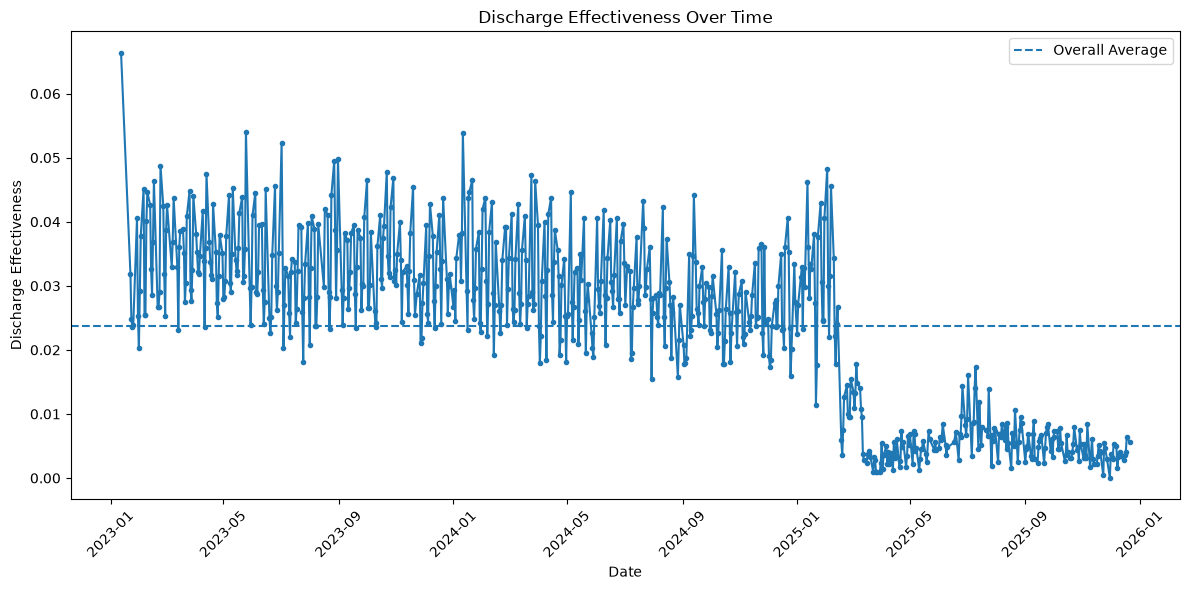

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["discharge_effectiveness"],
    marker="o",
    markersize=3
)

plt.axhline(
    df["discharge_effectiveness"].mean(),
    linestyle="--",
    label="Overall Average"
)

plt.title("Discharge Effectiveness Over Time")
plt.xlabel("Date")
plt.ylabel("Discharge Effectiveness")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Figure 2: Discharge Effectiveness Over Time

### Key Finding

Discharge effectiveness changes across reporting periods, reflecting variation in discharge activity relative to the HHS care population.

### Business Implication

Periods of comparatively low discharge effectiveness can be investigated alongside HHS operational pressure to identify potential periods requiring additional attention.

## 5.3 Pipeline Throughput Analysis

### Business Question

How does overall pipeline outflow compare with inflow?

### Description

Pipeline Throughput compares total recorded exits with total recorded entries over the observation period.

For this analysis, apprehensions are treated as the primary recorded inflow and discharges as the final recorded outflow.

In [6]:
total_entries = df["apprehended"].sum()
total_exits = df["discharged"].sum()

pipeline_throughput = total_exits / total_entries

print(f"Total Entries: {total_entries:,}")
print(f"Total Exits: {total_exits:,}")
print(f"Pipeline Throughput Ratio: {pipeline_throughput:.3f}")

Total Entries: 67,337.0
Total Exits: 124,853.0
Pipeline Throughput Ratio: 1.854


In [7]:
# Calculate yearly throughput

df["year"] = df["date"].dt.year

yearly_throughput = (
    df.groupby("year")
    .agg(
        entries=("apprehended", "sum"),
        exits=("discharged", "sum")
    )
)

yearly_throughput["throughput_ratio"] = (
    yearly_throughput["exits"] /
    yearly_throughput["entries"]
)

yearly_throughput

,entries,exits,throughput_ratio
year,,,
2023,27056.0,66244.0,2.448403
2024,37166.0,51689.0,1.390760
2025,3115.0,6920.0,2.221509


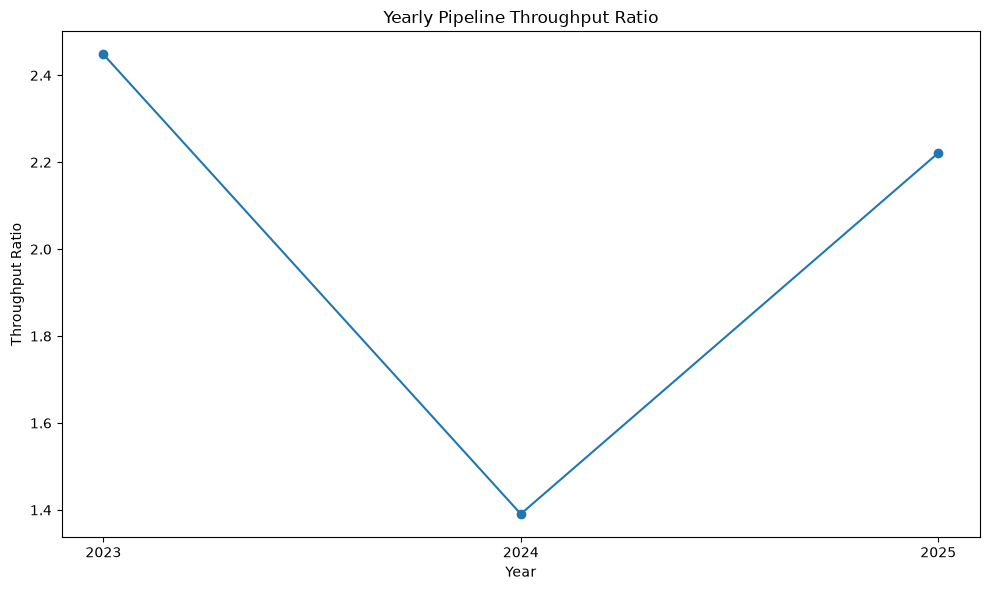

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_throughput.index,
    yearly_throughput["throughput_ratio"],
    marker="o"
)

plt.title("Yearly Pipeline Throughput Ratio")
plt.xlabel("Year")
plt.ylabel("Throughput Ratio")
plt.xticks(yearly_throughput.index)
plt.tight_layout()
plt.show()

### Figure 3: Yearly Pipeline Throughput Ratio

### Key Finding

The yearly throughput ratio shows how the relationship between recorded pipeline entries and exits changes across years.

### Business Implication

Changes in throughput provide a high-level indicator of whether recorded outflow activity is keeping pace with incoming activity across different years.

## 5.4 Efficiency Distribution

### Business Question

How much does transfer and discharge efficiency vary between reporting periods?

### Description

Distribution analysis is used to understand the typical range and variability of the two efficiency measures.

This helps distinguish normal variation from unusually high or low observations.

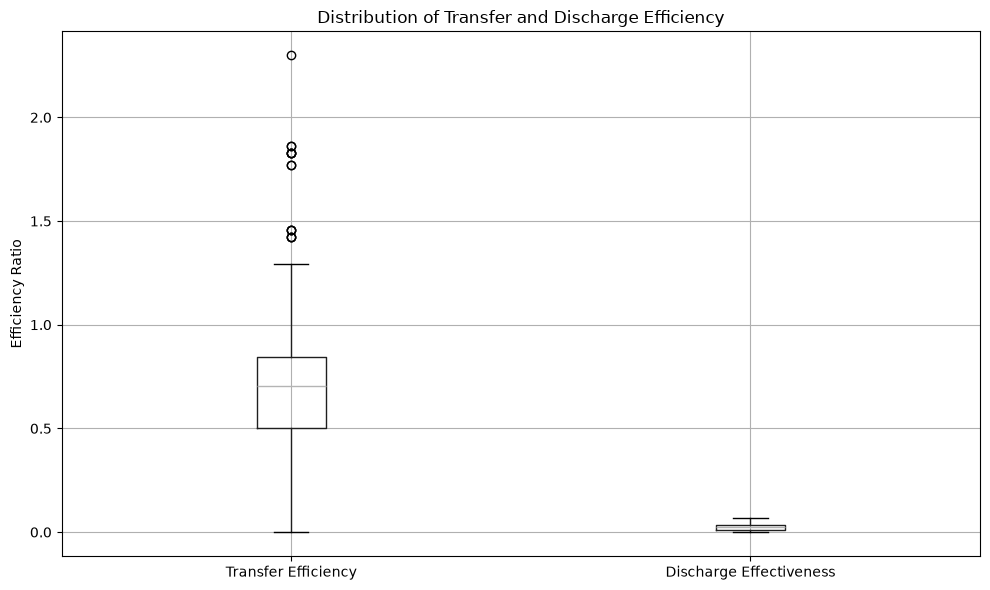

In [9]:
efficiency_data = df[
    ["transfer_efficiency", "discharge_effectiveness"]
].dropna()

plt.figure(figsize=(10, 6))

efficiency_data.boxplot()

plt.title("Distribution of Transfer and Discharge Efficiency")
plt.ylabel("Efficiency Ratio")
plt.xticks(
    [1, 2],
    ["Transfer Efficiency", "Discharge Effectiveness"]
)
plt.tight_layout()
plt.show()

### Figure 4: Distribution of Transfer and Discharge Efficiency

### Key Finding

The distributions show the typical range and variability of transfer and discharge efficiency across reporting periods.

### Business Implication

Large variability in an efficiency measure can indicate that operational performance is not consistent across reporting periods and may warrant further investigation.

## 5.5 Outcome Stability Analysis

### Business Question

How stable are transfer and discharge outcomes over time?

### Description

Outcome stability is assessed using the coefficient of variation (CV), which compares the standard deviation of an efficiency measure with its mean.

A lower CV indicates greater consistency, while a higher CV indicates greater variation.

In [10]:
transfer_mean = df["transfer_efficiency"].mean()
transfer_std = df["transfer_efficiency"].std()

discharge_mean = df["discharge_effectiveness"].mean()
discharge_std = df["discharge_effectiveness"].std()

transfer_cv = transfer_std / transfer_mean
discharge_cv = discharge_std / discharge_mean

stability_summary = pd.DataFrame({
    "Metric": [
        "Transfer Efficiency",
        "Discharge Effectiveness"
    ],
    "Mean": [
        transfer_mean,
        discharge_mean
    ],
    "Standard Deviation": [
        transfer_std,
        discharge_std
    ],
    "Coefficient of Variation": [
        transfer_cv,
        discharge_cv
    ]
})

stability_summary

,Metric,Mean,Standard Deviation,Coefficient of Variation
0,Transfer Efficiency,0.691018,0.309811,0.448340
1,Discharge Effectiveness,0.023737,0.013310,0.560727


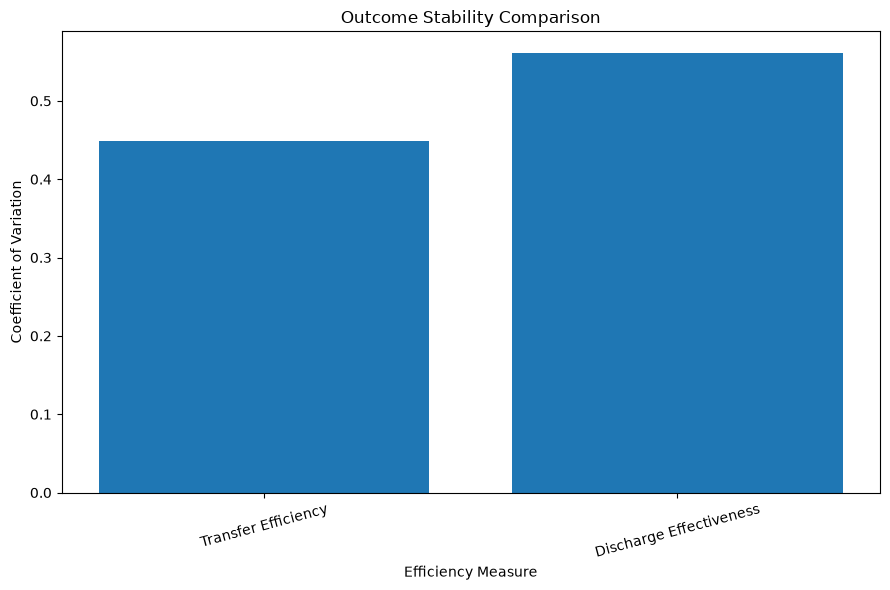

In [11]:
plt.figure(figsize=(9, 6))

plt.bar(
    stability_summary["Metric"],
    stability_summary["Coefficient of Variation"]
)

plt.title("Outcome Stability Comparison")
plt.xlabel("Efficiency Measure")
plt.ylabel("Coefficient of Variation")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Figure 5: Outcome Stability Comparison

### Key Finding

The coefficient of variation provides a standardized comparison of variability between transfer efficiency and discharge effectiveness.

The measure with the higher coefficient of variation shows greater relative variability across reporting periods.

### Business Implication

Understanding outcome stability helps identify which part of the care pipeline shows more consistent operational performance and which requires closer monitoring.

## 5.6 High and Low Efficiency Periods

### Business Question

Which reporting periods show unusually high or low efficiency?

### Description

The highest and lowest efficiency observations are identified to provide specific periods for further operational investigation.

In [12]:
low_transfer = (
    df.nsmallest(10, "transfer_efficiency")
    [["date", "cbp_custody", "transferred", "transfer_efficiency"]]
)

high_transfer = (
    df.nlargest(10, "transfer_efficiency")
    [["date", "cbp_custody", "transferred", "transfer_efficiency"]]
)

low_discharge = (
    df.nsmallest(10, "discharge_effectiveness")
    [["date", "hhs_care", "discharged", "discharge_effectiveness"]]
)

high_discharge = (
    df.nlargest(10, "discharge_effectiveness")
    [["date", "hhs_care", "discharged", "discharge_effectiveness"]]
)

print("Lowest Transfer Efficiency Periods")
display(low_transfer)

print("Highest Transfer Efficiency Periods")
display(high_transfer)

print("Lowest Discharge Effectiveness Periods")
display(low_discharge)

print("Highest Discharge Effectiveness Periods")
display(high_discharge)

Lowest Transfer Efficiency Periods


,date,cbp_custody,transferred,transfer_efficiency
533,2025-03-17,14.0,0.0,0.000000
607,2025-07-09,18.0,0.0,0.000000
612,2025-07-16,9.0,0.0,0.000000
520,2025-02-26,21.0,1.0,0.047619
646,2025-09-04,40.0,2.0,0.050000
635,2025-08-19,35.0,3.0,0.085714
669,2025-10-07,45.0,4.0,0.088889
712,2025-12-10,54.0,5.0,0.092593
698,2025-11-19,32.0,3.0,0.093750
530,2025-03-12,18.0,2.0,0.111111


Highest Transfer Efficiency Periods


,date,cbp_custody,transferred,transfer_efficiency
512,2025-02-13,10.0,23.0,2.300000
4,2023-01-25,22.0,41.0,1.863636
503,2025-02-02,22.0,41.0,1.863636
97,2023-06-13,64.0,117.0,1.828125
186,2023-10-25,64.0,117.0,1.828125
235,2024-01-08,64.0,117.0,1.828125
495,2025-01-21,64.0,117.0,1.828125
9,2023-02-02,13.0,23.0,1.769231
508,2025-02-09,13.0,23.0,1.769231
197,2023-11-12,160.0,233.0,1.456250


Lowest Discharge Effectiveness Periods


,date,hhs_care,discharged,discharge_effectiveness
704,2025-11-30,2415,0.0,0.000000
700,2025-11-23,2375,1.0,0.000421
542,2025-03-30,2188,2.0,0.000914
540,2025-03-26,2159,2.0,0.000926
541,2025-03-27,2159,2.0,0.000926
537,2025-03-23,2136,2.0,0.000936
573,2025-05-11,2385,3.0,0.001258
553,2025-04-13,2283,3.0,0.001314
545,2025-04-02,2208,3.0,0.001359
633,2025-08-17,1991,3.0,0.001507


Highest Discharge Effectiveness Periods


,date,hhs_care,discharged,discharge_effectiveness
0,2023-01-12,6566,436.0,0.066403
85,2023-05-25,7546,408.0,0.054068
238,2024-01-11,8829,476.0,0.053913
109,2023-07-02,5903,309.0,0.052346
149,2023-08-31,10140,505.0,0.049803
145,2023-08-27,9873,488.0,0.049428
23,2023-02-23,7914,386.0,0.048774
503,2025-02-02,3483,168.0,0.048234
183,2023-10-22,9506,454.0,0.047759
55,2023-04-13,7795,370.0,0.047466


### Key Finding

The extreme-value analysis identifies specific reporting periods where transfer or discharge efficiency differs substantially from typical observations.

### Business Implication

These periods can be used as case points for deeper investigation and can also support the threshold-based alerts used later in the dashboard.

## 5.7 KPI Summary

### Business Question

What are the main efficiency indicators for the UAC care pipeline?

### Description

The KPI summary consolidates the primary efficiency measures developed during this phase into a single analytical view.

In [13]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Average Transfer Efficiency",
        "Average Discharge Effectiveness",
        "Overall Pipeline Throughput",
        "Transfer Efficiency CV",
        "Discharge Effectiveness CV"
    ],
    "Value": [
        df["transfer_efficiency"].mean(),
        df["discharge_effectiveness"].mean(),
        pipeline_throughput,
        transfer_cv,
        discharge_cv
    ]
})

kpi_summary

,KPI,Value
0,Average Transfer Efficiency,0.691018
1,Average Discharge Effectiveness,0.023737
2,Overall Pipeline Throughput,1.854152
3,Transfer Efficiency CV,0.448340
4,Discharge Effectiveness CV,0.560727




### Key Finding

The KPI summary provides a consolidated view of transfer efficiency, discharge effectiveness, pipeline throughput, and outcome stability.

### Business Implication

These KPIs can be used as the core analytical indicators for monitoring the UAC care pipeline and can later be incorporated into the Streamlit dashboard.

## Executive Summary

### Key Findings

- Transfer efficiency varies across reporting periods relative to the CBP custody population.
- Discharge effectiveness varies relative to the HHS care population.
- Pipeline throughput provides a high-level measure of the relationship between recorded entries and exits.
- Efficiency distributions reveal the degree of variation across reporting periods.
- Outcome stability analysis identifies which efficiency measure has greater relative variability.
- High- and low-efficiency periods provide specific observations for further operational investigation.

### Conclusion

This analysis converts the care pipeline analysis into measurable efficiency and outcome indicators. Transfer Efficiency, Discharge Effectiveness, Pipeline Throughput, and Outcome Stability provide complementary measures for evaluating operational performance.

These indicators establish the analytical foundation for the later dashboard, where KPIs, thresholds, trends, and high-pressure periods can be presented to support operational monitoring and decision-making.